
# Lumen Technologies (LUMN): Pre- and Post-2024 Structural Break Analysis

This notebook focuses on whether Lumen Technologies' equity and fundamentals changed materially after the 2024 restructuring/turnaround period. It does **not** replace the broader financial-analysis notebook; it is a focused companion notebook built around a single question:

> Did LUMN become a different firm/security after 2024?

The analysis compares pre-2024 and post-2024 behavior across:

1. stock returns, volatility, drawdowns, skewness, and kurtosis;
2. Fama-French 5-factor loadings using monthly and daily data;
3. implied cost of equity estimates before and after the structural break;
4. rolling beta and alpha estimates;
5. 153-factor JKP-style factor exposures before and after 2024;
6. simple predictive factor screens before and after 2024;
7. fundamental ratios before and after 2024; and
8. peer-context comparisons where useful.

## Main assumption

The baseline break date is **2024-01-01**. This is editable in the assumptions cell below. Users may change the break date to test whether the estimated structural break is sensitive to timing.


In [1]:

# Core imports
from pathlib import Path
import zipfile, re, warnings, math
from io import StringIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)

# Plot defaults. No hard-coded colors, so the notebook uses matplotlib defaults.
plt.rcParams['figure.figsize'] = (10, 5.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False



## 1. Assumptions and file paths

All key assumptions are centralized here. The main parameter to vary is `break_date`. The cost-of-equity estimates use factor-premia assumptions that can be replaced with the user's preferred expected premia.


In [2]:

ASSUMPTIONS = {
    'break_date': '2024-01-01',
    'analysis_start_date': '2010-01-01',
    'annual_trading_days': 252,
    'annual_months': 12,
    # Forward-looking annual factor premia assumptions used to translate factor betas into cost of equity.
    # These are deliberately editable. They are not historical means by default.
    'annual_market_premium': 0.055,
    'annual_smb_premium': 0.015,
    'annual_hml_premium': 0.020,
    'annual_rmw_premium': 0.015,
    'annual_cma_premium': 0.015,
    'annual_risk_free_rate': 0.045,
    # JKP screening settings
    'jkp_min_obs_pre': 60,
    'jkp_min_obs_post': 18,
    'jkp_top_n': 25,
    'jkp_prediction_lag_months': 1,
    'ml_max_features': 60,
    'ml_min_train_obs': 60,
    # Peer accounting currency caveat
    'eurusd_accounting_translation_rate': 1.08,
}

PATHS = {
    'lumn_zip': Path('/mnt/data/LUMN.zip'),
    'peers_zip': Path('/mnt/data/LUMN_peers.zip'),
    'ff5_monthly_zip': Path('/mnt/data/F-F_Research_Data_5_Factors_2x3_CSV (1).zip'),
    'ff5_daily_zip': Path('/mnt/data/F-F_Research_Data_5_Factors_2x3_daily_CSV.zip'),
    'jkp153_monthly_zip': Path('/mnt/data/[usa]_[all_factors]_[monthly]_[vw_cap]_[factor] (1).zip'),
}

for k, p in PATHS.items():
    if not p.exists():
        candidate = Path.cwd() / p.name
        if candidate.exists():
            PATHS[k] = candidate

pd.DataFrame({'path': {k: str(v) for k, v in PATHS.items()}, 'exists': {k: v.exists() for k, v in PATHS.items()}})


,path,exists
lumn_zip,/mnt/data/LUMN.zip,True
peers_zip,/mnt/data/LUMN_peers.zip,True
ff5_monthly_zip,/mnt/data/F-F_Research_Data_5_Factors_2x3_CSV ...,True
ff5_daily_zip,/mnt/data/F-F_Research_Data_5_Factors_2x3_dail...,True
jkp153_monthly_zip,/mnt/data/[usa]_[all_factors]_[monthly]_[vw_ca...,True



## 2. Helper functions


In [3]:

def read_csv_from_zip(zip_path, member_contains=None):
    '''Read a CSV from a zip archive. If member_contains is supplied, the first member containing that substring is used.'''
    zip_path = Path(zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        names = [n for n in z.namelist() if n.lower().endswith('.csv')]
        if member_contains:
            names = [n for n in names if member_contains.lower() in n.lower()]
        if not names:
            raise FileNotFoundError(f'No CSV matching {member_contains} in {zip_path}')
        name = names[0]
        with z.open(name) as f:
            df = pd.read_csv(f)
    df.attrs['source_member'] = name
    return df

def read_text_csv_from_zip(zip_path, member_contains=None, encoding='latin1'):
    zip_path = Path(zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        names = [n for n in z.namelist() if n.lower().endswith('.csv')]
        if member_contains:
            names = [n for n in names if member_contains.lower() in n.lower()]
        if not names:
            raise FileNotFoundError(f'No CSV matching {member_contains} in {zip_path}')
        name = names[0]
        text = z.read(name).decode(encoding, errors='ignore')
    return name, text

def load_ken_french_zip(zip_path, freq='monthly'):
    '''Load a zipped Ken French CSV whose return columns are in percent.'''
    member, text = read_text_csv_from_zip(zip_path)
    lines = text.splitlines()
    header_idx = None
    for i, line in enumerate(lines):
        if line.startswith(',') and 'Mkt-RF' in line:
            header_idx = i
            break
    if header_idx is None:
        raise ValueError(f'Could not find factor header in {zip_path}')
    data_lines = []
    for line in lines[header_idx:]:
        if line.strip() == '' and len(data_lines) > 1:
            break
        if line.lower().startswith('annual'):
            break
        data_lines.append(line)
    df = pd.read_csv(StringIO('\n'.join(data_lines)))
    first = df.columns[0]
    df = df.rename(columns={first: 'date_code'})
    df = df[pd.to_numeric(df['date_code'], errors='coerce').notna()].copy()
    df['date_code'] = df['date_code'].astype(str).str.strip()
    if freq == 'daily':
        df['date'] = pd.to_datetime(df['date_code'], format='%Y%m%d')
    else:
        df['date'] = pd.to_datetime(df['date_code'], format='%Y%m') + pd.offsets.MonthEnd(0)
    df = df.drop(columns=['date_code']).set_index('date').sort_index()
    df.columns = [c.strip().replace('Mkt_RF','Mkt-RF') for c in df.columns]
    for c in df.columns:
        df[c] = pd.to_numeric(df[c], errors='coerce') / 100.0
    df.attrs['source_member'] = member
    return df

def clean_price_data(df, date_col='Date'):
    out = df.copy()
    # yfinance-like CSVs often have Date or Price/date columns.
    date_candidates = [c for c in out.columns if c.lower() in ['date','datetime','price']]
    if date_col not in out.columns and date_candidates:
        date_col = date_candidates[0]
    out[date_col] = pd.to_datetime(out[date_col], errors='coerce')
    out = out.dropna(subset=[date_col]).set_index(date_col).sort_index()
    for c in out.columns:
        out[c] = pd.to_numeric(out[c], errors='coerce')
    return out

def pick_price_col(df):
    for c in ['Adj Close', 'Close', 'adjclose', 'close']:
        if c in df.columns:
            return c
    num_cols = df.select_dtypes('number').columns.tolist()
    if not num_cols:
        raise ValueError('No numeric price columns found')
    return num_cols[0]

def ann_return_from_periodic(r, periods):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return np.nan
    return (1+r).prod()**(periods/len(r)) - 1

def return_stats(r, periods_per_year, label=None):
    r = pd.Series(r).dropna()
    if len(r) == 0:
        return pd.Series(dtype=float)
    cum = (1+r).prod() - 1
    wealth = (1+r).cumprod()
    dd = wealth / wealth.cummax() - 1
    return pd.Series({
        'n_obs': len(r),
        'cumulative_return': cum,
        'annualized_mean_arithmetic': r.mean()*periods_per_year,
        'annualized_geometric': ann_return_from_periodic(r, periods_per_year),
        'annualized_volatility': r.std()*np.sqrt(periods_per_year),
        'sharpe_ex_rf0': (r.mean()*periods_per_year)/(r.std()*np.sqrt(periods_per_year)) if r.std() else np.nan,
        'skewness': r.skew(),
        'excess_kurtosis': r.kurt(),
        'max_drawdown': dd.min(),
        'best_period_return': r.max(),
        'worst_period_return': r.min(),
    }, name=label)

def fit_factor_model(ret, factors, periods_per_year, factor_cols=None):
    if factor_cols is None:
        factor_cols = [c for c in ['Mkt-RF','SMB','HML','RMW','CMA'] if c in factors.columns]
    df = pd.concat([ret.rename('ret'), factors], axis=1).dropna()
    if 'RF' in df.columns:
        df['excess_ret'] = df['ret'] - df['RF']
    else:
        df['excess_ret'] = df['ret']
    use_cols = [c for c in factor_cols if c in df.columns]
    X = sm.add_constant(df[use_cols])
    y = df['excess_ret']
    model = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': min(5, max(1, len(df)//20))})
    out = {
        'n_obs': len(df),
        'alpha_periodic': model.params.get('const', np.nan),
        'alpha_annualized_arithmetic': model.params.get('const', np.nan)*periods_per_year,
        'r2': model.rsquared,
        'adj_r2': model.rsquared_adj,
    }
    for c in use_cols:
        out[f'beta_{c}'] = model.params.get(c, np.nan)
        out[f't_{c}'] = model.tvalues.get(c, np.nan)
    out['model'] = model
    out['data'] = df
    return out

def cost_of_equity_from_betas(row, premia=ASSUMPTIONS):
    coe = premia['annual_risk_free_rate']
    coe += row.get('beta_Mkt-RF', np.nan) * premia['annual_market_premium']
    coe += row.get('beta_SMB', 0) * premia['annual_smb_premium']
    coe += row.get('beta_HML', 0) * premia['annual_hml_premium']
    coe += row.get('beta_RMW', 0) * premia['annual_rmw_premium']
    coe += row.get('beta_CMA', 0) * premia['annual_cma_premium']
    return coe

def bh_adjust(pvalues):
    p = pd.Series(pvalues, dtype=float)
    out = pd.Series(np.nan, index=p.index, dtype=float)
    valid = p.dropna().sort_values()
    m = len(valid)
    if m == 0:
        return out
    ranks = np.arange(1, m+1)
    adj = valid.values*m/ranks
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    out.loc[valid.index] = np.clip(adj,0,1)
    return out

def univariate_factor_screen(y, X, lag=0, min_obs=60):
    rows=[]
    y = y.rename('target')
    for col in X.columns:
        x = X[col].shift(lag) if lag else X[col]
        data = pd.concat([y, x.rename(col)], axis=1).dropna()
        if len(data) < min_obs or data[col].std() == 0:
            continue
        model = sm.OLS(data['target'], sm.add_constant(data[[col]])).fit(cov_type='HAC', cov_kwds={'maxlags': min(3, max(1, len(data)//20))})
        rows.append({
            'factor': col,
            'n_obs': len(data),
            'alpha': model.params.get('const', np.nan),
            'beta': model.params.get(col, np.nan),
            't_beta_HAC': model.tvalues.get(col, np.nan),
            'p_beta_HAC': model.pvalues.get(col, np.nan),
            'r2': model.rsquared,
            'corr': data['target'].corr(data[col]),
        })
    out = pd.DataFrame(rows)
    if not out.empty:
        out['p_beta_BH'] = bh_adjust(out.set_index('factor')['p_beta_HAC']).reindex(out['factor']).values
        out['abs_t'] = out['t_beta_HAC'].abs()
        out['abs_corr'] = out['corr'].abs()
    return out

def display_percent_table(df, pct_cols=None, digits=2):
    if pct_cols is None:
        pct_cols = [c for c in df.columns if any(k in c.lower() for k in ['return','mean','volatility','alpha','coe','drawdown','rf','premium'])]
    sty = df.copy()
    return sty.style.format({c: '{:.2%}' for c in pct_cols if c in sty.columns}).format(precision=digits)



## 3. Load LUMN prices, Fama-French 5 factors, and JKP 153 factors


In [4]:

# LUMN prices
lumn_daily = clean_price_data(read_csv_from_zip(PATHS['lumn_zip'], 'LUMN_daily'))
lumn_monthly = clean_price_data(read_csv_from_zip(PATHS['lumn_zip'], 'LUMN_monthly'))
# Yahoo monthly files are usually dated at month-start. Convert to month-end for factor alignment.
lumn_monthly.index = pd.to_datetime(lumn_monthly.index) + pd.offsets.MonthEnd(0)
lumn_monthly = lumn_monthly[~lumn_monthly.index.duplicated(keep='last')].sort_index()
price_col_daily = pick_price_col(lumn_daily)
price_col_monthly = pick_price_col(lumn_monthly)

lumn_daily['ret'] = lumn_daily[price_col_daily].pct_change()
lumn_monthly['ret'] = lumn_monthly[price_col_monthly].pct_change()
lumn_daily = lumn_daily.loc[ASSUMPTIONS['analysis_start_date']:]
lumn_monthly = lumn_monthly.loc[ASSUMPTIONS['analysis_start_date']:]

# Factor data
ff5_monthly = load_ken_french_zip(PATHS['ff5_monthly_zip'], freq='monthly')
ff5_daily = load_ken_french_zip(PATHS['ff5_daily_zip'], freq='daily')

# JKP 153-factor monthly long data -> wide factor matrix
jkp_long = read_csv_from_zip(PATHS['jkp153_monthly_zip'])
jkp_long['date'] = pd.to_datetime(jkp_long['date'])
jkp_long['ret'] = pd.to_numeric(jkp_long['ret'], errors='coerce')
jkp_long['name'] = jkp_long['name'].astype(str)
jkp_wide = jkp_long.pivot_table(index='date', columns='name', values='ret', aggfunc='mean').sort_index()
# Align to month-end to match LUMN monthly returns.
jkp_wide.index = pd.to_datetime(jkp_wide.index) + pd.offsets.MonthEnd(0)

print('LUMN daily:', lumn_daily.index.min().date(), 'to', lumn_daily.index.max().date(), '| rows:', len(lumn_daily), '| price column:', price_col_daily)
print('LUMN monthly:', lumn_monthly.index.min().date(), 'to', lumn_monthly.index.max().date(), '| rows:', len(lumn_monthly), '| price column:', price_col_monthly)
print('FF5 monthly columns:', ff5_monthly.columns.tolist())
print('FF5 daily columns:', ff5_daily.columns.tolist())
print('JKP monthly factor count:', jkp_wide.shape[1], '| dates:', jkp_wide.index.min().date(), 'to', jkp_wide.index.max().date())


LUMN daily: 2010-01-04 to 2026-06-05 | rows: 4131 | price column: Adj Close
LUMN monthly: 2010-01-31 to 2026-06-30 | rows: 198 | price column: Adj Close
FF5 monthly columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
FF5 daily columns: ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
JKP monthly factor count: 153 | dates: 1926-01-31 to 2025-12-31



## 4. Pre/post return behavior

The first question is whether the post-2024 return distribution looks like the same process as the pre-2024 period. We compare cumulative returns, volatility, skewness, kurtosis, and drawdowns.


In [5]:

break_date = pd.Timestamp(ASSUMPTIONS['break_date'])

monthly_ret = lumn_monthly['ret'].dropna()
daily_ret = lumn_daily['ret'].dropna()

periods = {
    'Pre-2024': monthly_ret.loc[:break_date - pd.Timedelta(days=1)],
    'Post-2024': monthly_ret.loc[break_date:],
    'Full sample': monthly_ret,
}
monthly_stats = pd.DataFrame([return_stats(v, 12, k) for k, v in periods.items()])
monthly_stats


,n_obs,cumulative_return,annualized_mean_arithmetic,annualized_geometric,annualized_volatility,sharpe_ex_rf0,skewness,excess_kurtosis,max_drawdown,best_period_return,worst_period_return
Pre-2024,168.0,-0.857174,-0.076875,-0.129780,0.347612,-0.221151,0.113491,1.957392,-0.936114,0.396947,-0.352381
Post-2024,30.0,3.868852,1.276598,0.883522,1.436543,0.888660,2.842296,10.811474,-0.517711,1.863636,-0.333333
Full sample,198.0,-0.304604,0.128197,-0.021776,0.652645,0.196427,5.272848,48.144492,-0.946356,1.863636,-0.352381


In [6]:

periods_d = {
    'Pre-2024': daily_ret.loc[:break_date - pd.Timedelta(days=1)],
    'Post-2024': daily_ret.loc[break_date:],
    'Full sample': daily_ret,
}
daily_stats = pd.DataFrame([return_stats(v, 252, k) for k, v in periods_d.items()])
daily_stats


,n_obs,cumulative_return,annualized_mean_arithmetic,annualized_geometric,annualized_volatility,sharpe_ex_rf0,skewness,excess_kurtosis,max_drawdown,best_period_return,worst_period_return
Pre-2024,3522.0,-0.857174,-0.055361,-0.129986,0.405708,-0.136455,-0.574552,22.366970,-0.952585,0.280948,-0.328767
Post-2024,609.0,3.868852,1.114680,0.925096,1.035406,1.076563,5.305239,69.498182,-0.696640,0.930502,-0.216312
Full sample,4131.0,-0.304604,0.117129,-0.021917,0.546659,0.214263,5.246253,142.289020,-0.952585,0.930502,-0.328767


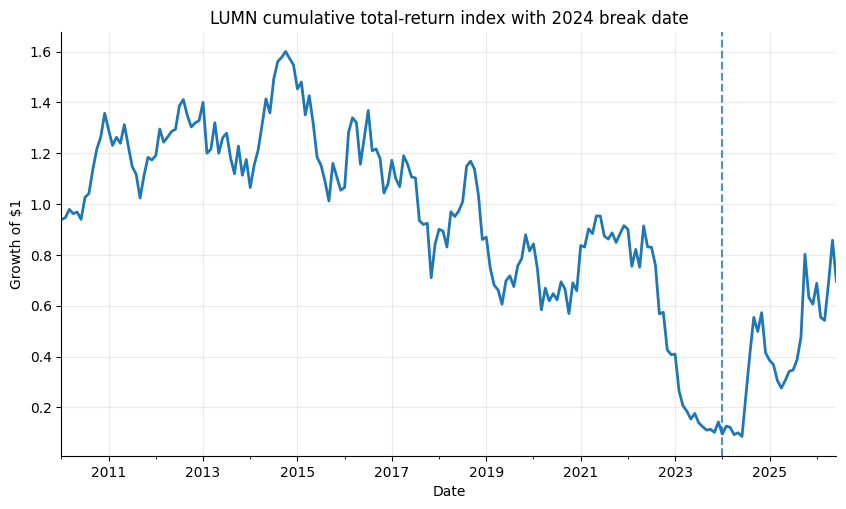

In [7]:

wealth = (1 + monthly_ret).cumprod()
fig, ax = plt.subplots()
wealth.plot(ax=ax, linewidth=2)
ax.axvline(break_date, linestyle='--', alpha=0.8)
ax.set_title('LUMN cumulative total-return index with 2024 break date')
ax.set_ylabel('Growth of $1')
ax.set_xlabel('Date')
plt.show()


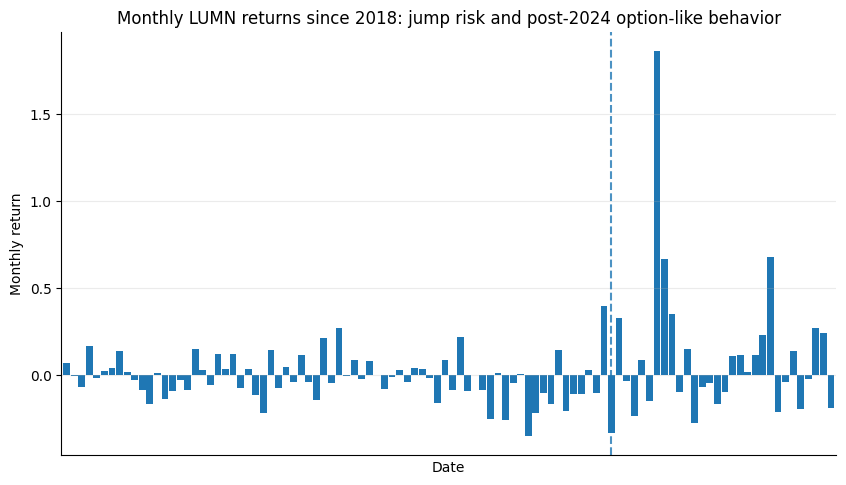

In [8]:

fig, ax = plt.subplots()
monthly_ret.loc['2018':].plot(ax=ax, kind='bar', width=0.9)
ax.axvline(len(monthly_ret.loc['2018':break_date - pd.Timedelta(days=1)]), linestyle='--', alpha=0.8)
ax.set_title('Monthly LUMN returns since 2018: jump risk and post-2024 option-like behavior')
ax.set_ylabel('Monthly return')
plt.xticks([])
plt.show()


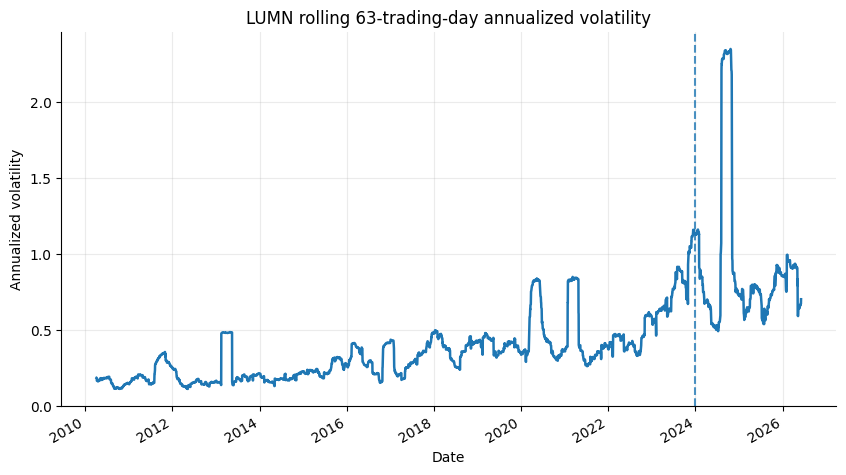

In [9]:

roll_vol = daily_ret.rolling(63).std()*np.sqrt(252)
fig, ax = plt.subplots()
roll_vol.plot(ax=ax, linewidth=1.8)
ax.axvline(break_date, linestyle='--', alpha=0.8)
ax.set_title('LUMN rolling 63-trading-day annualized volatility')
ax.set_ylabel('Annualized volatility')
plt.show()



## 5. Fama-French 5-factor loadings before and after 2024

We estimate separate regressions before and after the break date using both monthly and daily data. The daily regressions provide many more observations after 2024, while monthly regressions are more natural for long-horizon asset-pricing interpretation.


In [10]:

# Monthly FF5 regressions
monthly_factor_data = pd.concat([monthly_ret.rename('ret'), ff5_monthly], axis=1).dropna()
pre_month = monthly_factor_data.loc[:break_date - pd.Timedelta(days=1)]
post_month = monthly_factor_data.loc[break_date:]

ff5_cols = [c for c in ['Mkt-RF','SMB','HML','RMW','CMA'] if c in ff5_monthly.columns]
monthly_models = {
    'Monthly Pre-2024': fit_factor_model(pre_month['ret'], pre_month[ff5_monthly.columns], 12, ff5_cols),
    'Monthly Post-2024': fit_factor_model(post_month['ret'], post_month[ff5_monthly.columns], 12, ff5_cols),
    'Monthly Full sample': fit_factor_model(monthly_factor_data['ret'], monthly_factor_data[ff5_monthly.columns], 12, ff5_cols),
}

monthly_ff5_table = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk not in ['model','data']} for k, v in monthly_models.items()}).T
monthly_ff5_table['cost_of_equity_FF5'] = monthly_ff5_table.apply(cost_of_equity_from_betas, axis=1)
monthly_ff5_table['cost_of_equity_CAPM_only'] = ASSUMPTIONS['annual_risk_free_rate'] + monthly_ff5_table['beta_Mkt-RF']*ASSUMPTIONS['annual_market_premium']
monthly_ff5_table


,n_obs,alpha_periodic,alpha_annualized_arithmetic,r2,adj_r2,beta_Mkt-RF,t_Mkt-RF,beta_SMB,t_SMB,beta_HML,t_HML,beta_RMW,t_RMW,beta_CMA,t_CMA,cost_of_equity_FF5,cost_of_equity_CAPM_only
Monthly Pre-2024,168.0,-0.018040,-0.216481,0.211628,0.187296,0.886598,7.178819,0.267453,0.701535,-0.099192,-0.376239,0.169658,0.351875,1.311107,2.947717,0.118002,0.093763
Monthly Post-2024,28.0,0.118463,1.421553,0.343612,0.194433,1.038884,0.962893,7.406508,1.785333,-0.422017,-0.241236,-2.492860,-0.820852,-1.212064,-0.486203,0.149222,0.102139
Monthly Full sample,196.0,0.001624,0.019484,0.109242,0.085801,0.865221,3.441572,1.158531,0.944190,0.352532,0.834848,-0.314214,-0.311247,0.320258,0.434171,0.117106,0.092587


In [11]:

# Daily FF5 regressions
# Align daily stock returns with daily FF5 factors.
daily_factor_data = pd.concat([daily_ret.rename('ret'), ff5_daily], axis=1).dropna()
pre_day = daily_factor_data.loc[:break_date - pd.Timedelta(days=1)]
post_day = daily_factor_data.loc[break_date:]
ff5_cols_d = [c for c in ['Mkt-RF','SMB','HML','RMW','CMA'] if c in ff5_daily.columns]

daily_models = {
    'Daily Pre-2024': fit_factor_model(pre_day['ret'], pre_day[ff5_daily.columns], 252, ff5_cols_d),
    'Daily Post-2024': fit_factor_model(post_day['ret'], post_day[ff5_daily.columns], 252, ff5_cols_d),
    'Daily Full sample': fit_factor_model(daily_factor_data['ret'], daily_factor_data[ff5_daily.columns], 252, ff5_cols_d),
}

daily_ff5_table = pd.DataFrame({k: {kk: vv for kk, vv in v.items() if kk not in ['model','data']} for k, v in daily_models.items()}).T
daily_ff5_table['cost_of_equity_FF5'] = daily_ff5_table.apply(cost_of_equity_from_betas, axis=1)
daily_ff5_table['cost_of_equity_CAPM_only'] = ASSUMPTIONS['annual_risk_free_rate'] + daily_ff5_table['beta_Mkt-RF']*ASSUMPTIONS['annual_market_premium']
daily_ff5_table


,n_obs,alpha_periodic,alpha_annualized_arithmetic,r2,adj_r2,beta_Mkt-RF,t_Mkt-RF,beta_SMB,t_SMB,beta_HML,t_HML,beta_RMW,t_RMW,beta_CMA,t_CMA,cost_of_equity_FF5,cost_of_equity_CAPM_only
Daily Pre-2024,3522.0,-0.000793,-0.199726,0.201037,0.199901,0.938312,21.172090,0.375173,3.757752,0.173007,1.505399,0.324806,2.741240,0.806961,2.952503,0.122671,0.096607
Daily Post-2024,584.0,0.003405,0.857937,0.136019,0.128545,1.859873,8.275490,1.587324,5.470392,-0.073517,-0.210468,0.151947,0.258122,-0.961951,-1.547763,0.157482,0.147293
Daily Full sample,4106.0,-0.000138,-0.034850,0.136094,0.135040,1.025029,18.705446,0.532339,4.965043,0.160846,1.382086,0.156429,0.970246,0.573253,2.078465,0.123524,0.101377


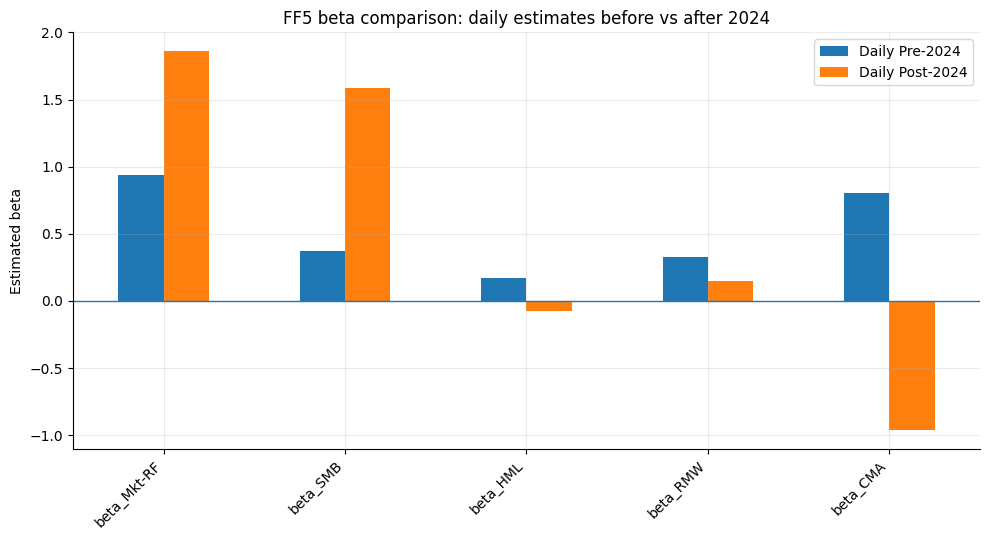

In [12]:

# Visualize beta changes from daily model
beta_cols = [c for c in daily_ff5_table.columns if c.startswith('beta_')]
plot_beta = daily_ff5_table.loc[['Daily Pre-2024','Daily Post-2024'], beta_cols].T
fig, ax = plt.subplots()
plot_beta.plot(kind='bar', ax=ax)
ax.axhline(0, linewidth=1)
ax.set_title('FF5 beta comparison: daily estimates before vs after 2024')
ax.set_ylabel('Estimated beta')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


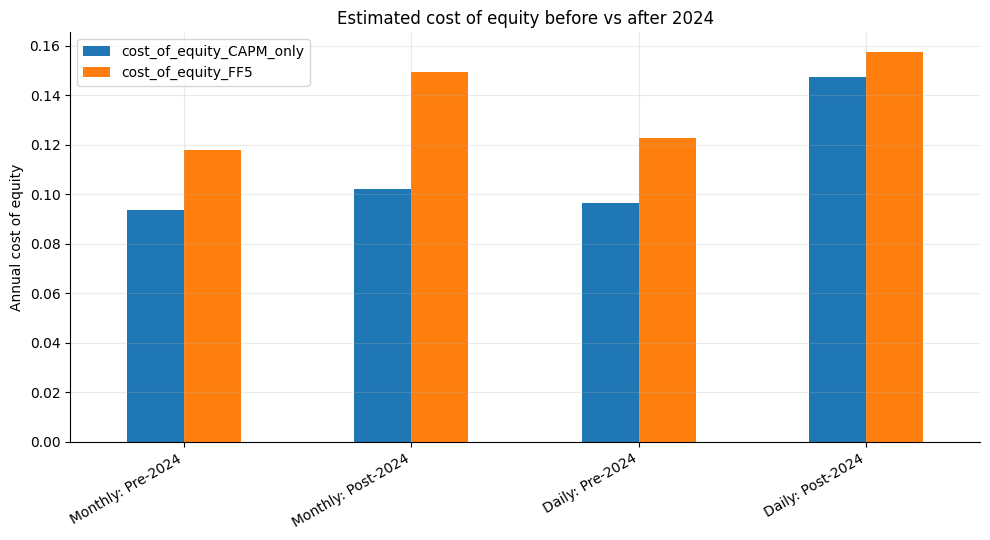

,cost_of_equity_CAPM_only,cost_of_equity_FF5
Monthly: Pre-2024,0.093763,0.118002
Monthly: Post-2024,0.102139,0.149222
Monthly: Full sample,0.092587,0.117106
Daily: Pre-2024,0.096607,0.122671
Daily: Post-2024,0.147293,0.157482
Daily: Full sample,0.101377,0.123524


In [13]:

coe = pd.concat([
    monthly_ff5_table[['cost_of_equity_CAPM_only','cost_of_equity_FF5']].rename(index=lambda x: x.replace('Monthly ', 'Monthly: ')),
    daily_ff5_table[['cost_of_equity_CAPM_only','cost_of_equity_FF5']].rename(index=lambda x: x.replace('Daily ', 'Daily: ')),
])
fig, ax = plt.subplots()
coe.loc[[i for i in coe.index if 'Pre-2024' in i or 'Post-2024' in i]].plot(kind='bar', ax=ax)
ax.set_title('Estimated cost of equity before vs after 2024')
ax.set_ylabel('Annual cost of equity')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
coe



## 6. Rolling factor exposures

A split-sample regression is useful, but a rolling regression shows whether the change was sudden or gradual. The next cells estimate rolling daily CAPM beta and FF5 alpha/beta using 252-trading-day windows.


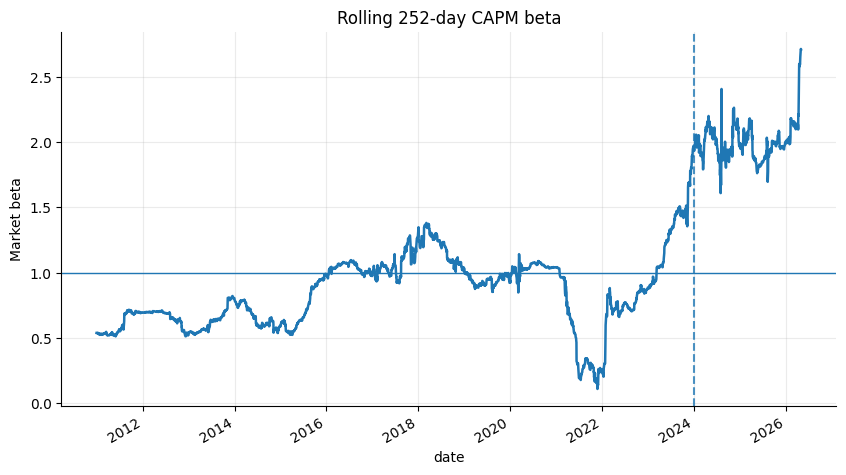

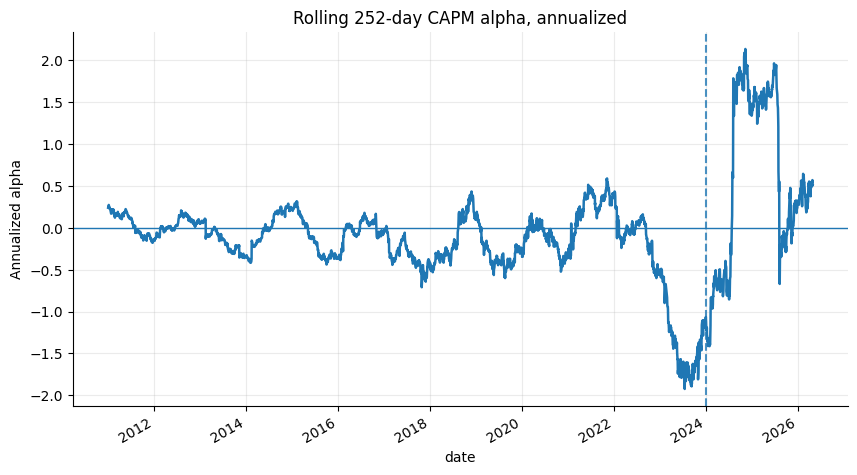

In [14]:

def rolling_capm(daily_factor_data, window=252):
    rows=[]
    df = daily_factor_data[['ret','RF','Mkt-RF']].dropna().copy()
    df['excess_ret'] = df['ret'] - df['RF']
    for i in range(window, len(df)+1):
        sub = df.iloc[i-window:i]
        model = sm.OLS(sub['excess_ret'], sm.add_constant(sub[['Mkt-RF']])).fit()
        rows.append({'date': sub.index[-1], 'alpha_ann': model.params['const']*252, 'beta_mkt': model.params['Mkt-RF'], 'r2': model.rsquared})
    return pd.DataFrame(rows).set_index('date')

roll_capm = rolling_capm(daily_factor_data, window=252)
fig, ax = plt.subplots()
roll_capm['beta_mkt'].plot(ax=ax, linewidth=1.8)
ax.axvline(break_date, linestyle='--', alpha=0.8)
ax.axhline(1, linewidth=1)
ax.set_title('Rolling 252-day CAPM beta')
ax.set_ylabel('Market beta')
plt.show()

fig, ax = plt.subplots()
roll_capm['alpha_ann'].plot(ax=ax, linewidth=1.8)
ax.axvline(break_date, linestyle='--', alpha=0.8)
ax.axhline(0, linewidth=1)
ax.set_title('Rolling 252-day CAPM alpha, annualized')
ax.set_ylabel('Annualized alpha')
plt.show()



## 7. Statistical break tests

A simple Chow-style nested regression asks whether post-2024 interaction terms materially improve the factor model. The interaction terms test whether alpha and betas changed after the restructuring period began.


In [15]:

def interaction_break_test(df, factors, freq_label):
    d = df.copy().dropna()
    d['excess_ret'] = d['ret'] - d['RF']
    d['post2024'] = (d.index >= break_date).astype(int)
    X = d[factors].copy()
    X['post2024'] = d['post2024']
    for f in factors:
        X[f'{f}_x_post'] = d[f]*d['post2024']
    X = sm.add_constant(X)
    model = sm.OLS(d['excess_ret'], X).fit(cov_type='HAC', cov_kwds={'maxlags': min(5, max(1, len(d)//20))})
    rows=[]
    for name in ['post2024'] + [f'{f}_x_post' for f in factors]:
        rows.append({'term': name, 'coef': model.params.get(name,np.nan), 't_HAC': model.tvalues.get(name,np.nan), 'p_HAC': model.pvalues.get(name,np.nan)})
    return model, pd.DataFrame(rows)

m_break_monthly, break_monthly_table = interaction_break_test(monthly_factor_data, ff5_cols, 'monthly')
m_break_daily, break_daily_table = interaction_break_test(daily_factor_data, ff5_cols_d, 'daily')

print('Monthly interaction/break terms')
display(break_monthly_table)
print('\nDaily interaction/break terms')
display(break_daily_table)


Monthly interaction/break terms


,term,coef,t_HAC,p_HAC
0,post2024,0.136503,1.390954,0.164240
1,Mkt-RF_x_post,0.152286,0.178650,0.858213
2,SMB_x_post,7.139054,1.877188,0.060492
3,HML_x_post,-0.322825,-0.198917,0.842328
4,RMW_x_post,-2.662518,-0.893408,0.371639
5,CMA_x_post,-2.523171,-1.091969,0.274847



Daily interaction/break terms


,term,coef,t_HAC,p_HAC
0,post2024,0.004197,1.493544,0.135295
1,Mkt-RF_x_post,0.921561,4.023005,0.000057
2,SMB_x_post,1.212151,3.950056,0.000078
3,HML_x_post,-0.246524,-0.670434,0.502581
4,RMW_x_post,-0.172859,-0.287852,0.773460
5,CMA_x_post,-1.768912,-2.605313,0.009179



## 8. JKP 153-factor comparison before and after 2024

This section asks whether LUMN's broad factor signature changed after 2024. The contemporaneous screen is diagnostic: it describes the kinds of factor returns that co-move with LUMN. The lagged screen is predictive: it asks whether factor returns in month *t-1* predict LUMN's return in month *t*.

The post-2024 sample is short. As a result, post-2024 JKP results should be interpreted as exploratory rather than definitive.


In [16]:

# Align LUMN monthly excess returns with JKP factors.
jkp_panel = pd.concat([monthly_ret.rename('LUMN_ret'), jkp_wide], axis=1).dropna(subset=['LUMN_ret'])
pre_jkp = jkp_panel.loc[:break_date - pd.Timedelta(days=1)]
post_jkp = jkp_panel.loc[break_date:]

X_pre = pre_jkp.drop(columns=['LUMN_ret'])
y_pre = pre_jkp['LUMN_ret']
X_post = post_jkp.drop(columns=['LUMN_ret'])
y_post = post_jkp['LUMN_ret']

print('Pre-2024 JKP sample:', y_pre.index.min().date(), 'to', y_pre.index.max().date(), '| n=', len(y_pre))
print('Post-2024 JKP sample:', y_post.index.min().date(), 'to', y_post.index.max().date(), '| n=', len(y_post))
print('Number of candidate JKP factors:', X_pre.shape[1])


Pre-2024 JKP sample: 2010-01-31 to 2023-12-31 | n= 168
Post-2024 JKP sample: 2024-01-31 to 2026-06-30 | n= 30
Number of candidate JKP factors: 153


In [17]:

pre_contemp = univariate_factor_screen(y_pre, X_pre, lag=0, min_obs=ASSUMPTIONS['jkp_min_obs_pre']).sort_values('abs_t', ascending=False)
post_contemp = univariate_factor_screen(y_post, X_post, lag=0, min_obs=ASSUMPTIONS['jkp_min_obs_post']).sort_values('abs_t', ascending=False)

print('Top contemporaneous JKP factors, pre-2024')
display(pre_contemp.head(ASSUMPTIONS['jkp_top_n']))
print('\nTop contemporaneous JKP factors, post-2024')
display(post_contemp.head(ASSUMPTIONS['jkp_top_n']))


Top contemporaneous JKP factors, pre-2024


,factor,n_obs,alpha,beta,t_beta_HAC,p_beta_HAC,r2,corr,p_beta_BH,abs_t,abs_corr
107,qmj_safety,168,-0.006495,-1.558739,-7.333120,2.248556e-13,0.160069,-0.400086,3.440290e-11,7.333120,0.400086
102,prc,168,-0.003520,1.234542,5.297361,1.174886e-07,0.134591,0.366867,8.335770e-06,5.297361,0.366867
104,qmj,168,-0.003982,-1.377657,-5.236730,1.634465e-07,0.110507,-0.332426,8.335770e-06,5.236730,0.332426
10,beta_60m,168,-0.007014,-0.729000,-4.835526,1.327938e-06,0.094771,-0.307850,5.079362e-05,4.835526,0.307850
103,prc_highprc_252d,168,-0.003986,-0.767439,-4.766316,1.876251e-06,0.113907,-0.337501,5.741329e-05,4.766316,0.337501
64,kz_index,168,-0.001729,1.753716,4.560066,5.113764e-06,0.100260,0.316639,1.304010e-04,4.560066,0.316639
129,sale_me,168,-0.009403,0.993967,4.211030,2.542087e-05,0.097397,0.312084,5.556277e-04,4.211030,0.312084
12,betabab_1260d,168,-0.006952,-0.573500,-3.929711,8.504804e-05,0.068043,-0.260851,1.483225e-03,3.929711,0.260851
14,bev_mev,168,-0.005533,0.888218,3.920910,8.821524e-05,0.081753,0.285924,1.483225e-03,3.920910,0.285924
72,netdebt_me,168,-0.004955,-1.015780,-3.879560,1.046455e-04,0.073047,-0.270273,1.483225e-03,3.879560,0.270273



Top contemporaneous JKP factors, post-2024


,factor,n_obs,alpha,beta,t_beta_HAC,p_beta_HAC,r2,corr,p_beta_BH,abs_t,abs_corr
76,ni_be,24,0.109451,-6.676582,-3.387947,0.000704,0.107062,-0.327203,0.053132,3.387947,0.327203
97,ope_be,24,0.107823,-6.312825,-3.342425,0.000830,0.096654,-0.310893,0.053132,3.342425,0.310893
98,ope_bel1,24,0.115348,-7.005740,-3.278986,0.001042,0.109043,-0.330216,0.053132,3.278986,0.330216
40,ebit_bev,24,0.124156,-7.841623,-3.065692,0.002172,0.100327,-0.316745,0.083066,3.065692,0.316745
106,qmj_prof,24,0.065580,-15.696945,-2.699338,0.006948,0.380445,-0.616802,0.212602,2.699338,0.616802
82,niq_be,24,0.123578,-11.024664,-2.612426,0.008990,0.237106,-0.486935,0.229251,2.612426,0.486935
45,eqnetis_at,24,0.052748,-12.776703,-2.508020,0.012141,0.155618,-0.394484,0.235069,2.508020,0.394484
88,o_score,24,0.161637,-20.047856,-2.503673,0.012291,0.358858,-0.599047,0.235069,2.503673,0.599047
24,cop_at,24,0.092852,-16.394757,-2.249445,0.024484,0.348444,-0.590291,0.361347,2.249445,0.590291
73,netis_at,24,0.105022,-21.751242,-2.229033,0.025812,0.295334,-0.543446,0.361347,2.229033,0.543446


In [18]:

# Compare factor correlations directly where enough data exist in both periods.
def corr_with_lumn(y, X, min_obs):
    rows=[]
    for c in X.columns:
        d = pd.concat([y.rename('y'), X[c].rename(c)], axis=1).dropna()
        if len(d) >= min_obs:
            rows.append({'factor': c, 'corr': d['y'].corr(d[c]), 'n_obs': len(d)})
    return pd.DataFrame(rows)

pre_corr = corr_with_lumn(y_pre, X_pre, ASSUMPTIONS['jkp_min_obs_pre']).rename(columns={'corr':'corr_pre', 'n_obs':'n_pre'})
post_corr = corr_with_lumn(y_post, X_post, ASSUMPTIONS['jkp_min_obs_post']).rename(columns={'corr':'corr_post', 'n_obs':'n_post'})
corr_change = pre_corr.merge(post_corr, on='factor', how='inner')
corr_change['change'] = corr_change['corr_post'] - corr_change['corr_pre']
corr_change['abs_change'] = corr_change['change'].abs()
corr_change = corr_change.sort_values('abs_change', ascending=False)
corr_change.head(30)


,factor,corr_pre,n_pre,corr_post,n_post,change,abs_change
39,earnings_variability,-0.233485,168,0.426190,24,0.659675,0.659675
90,oaccruals_ni,0.220010,168,-0.321427,24,-0.541437,0.541437
73,netis_at,-0.026616,168,-0.543446,24,-0.516830,0.516830
24,cop_at,-0.119494,168,-0.590291,24,-0.470797,0.470797
29,dbnetis_at,0.094188,168,-0.372290,24,-0.466478,0.466478
106,qmj_prof,-0.191939,168,-0.616802,24,-0.424863,0.424863
89,oaccruals_at,0.143022,168,-0.281627,24,-0.424649,0.424649
25,cop_atl1,-0.125839,168,-0.549027,24,-0.423187,0.423187
95,op_at,-0.161999,168,-0.576321,24,-0.414322,0.414322
34,dolvol_126d,0.064940,168,0.471078,24,0.406138,0.406138


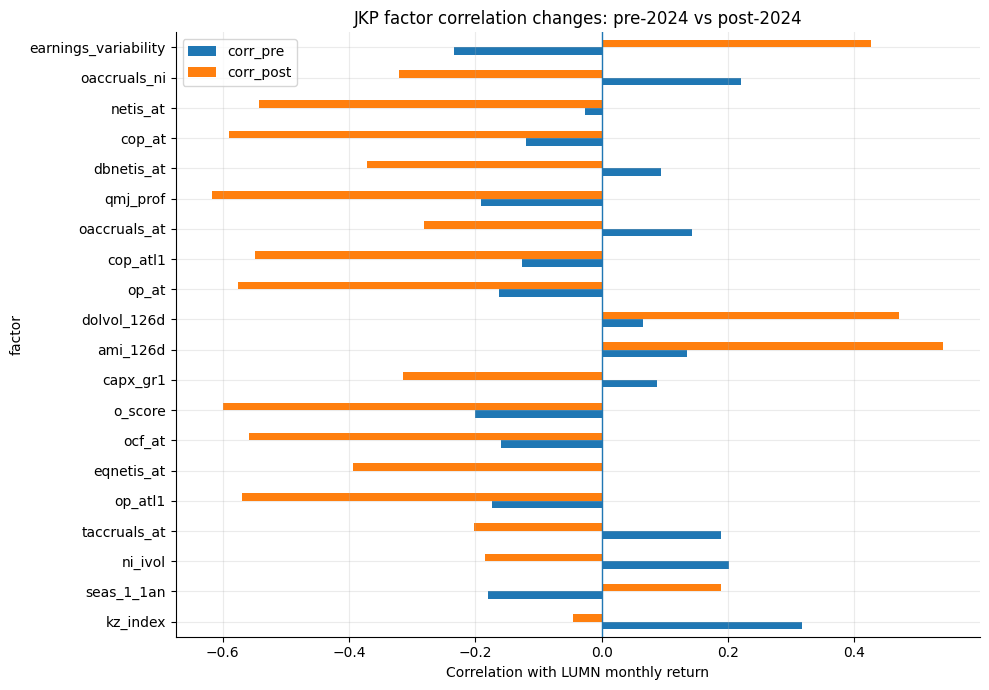

In [19]:

# Plot the biggest correlation changes
plot_df = corr_change.head(20).set_index('factor')[['corr_pre','corr_post']]
fig, ax = plt.subplots(figsize=(10, 7))
plot_df.iloc[::-1].plot(kind='barh', ax=ax)
ax.axvline(0, linewidth=1)
ax.set_title('JKP factor correlation changes: pre-2024 vs post-2024')
ax.set_xlabel('Correlation with LUMN monthly return')
plt.tight_layout()
plt.show()


In [20]:

pre_predictive = univariate_factor_screen(y_pre, X_pre, lag=ASSUMPTIONS['jkp_prediction_lag_months'], min_obs=ASSUMPTIONS['jkp_min_obs_pre']).sort_values('abs_t', ascending=False)
post_predictive = univariate_factor_screen(y_post, X_post, lag=ASSUMPTIONS['jkp_prediction_lag_months'], min_obs=max(12, ASSUMPTIONS['jkp_min_obs_post']-1)).sort_values('abs_t', ascending=False)

print('Top lagged/predictive JKP factors, pre-2024')
display(pre_predictive.head(ASSUMPTIONS['jkp_top_n']))
print('\nTop lagged/predictive JKP factors, post-2024 - exploratory because n is small')
display(post_predictive.head(ASSUMPTIONS['jkp_top_n']))


Top lagged/predictive JKP factors, pre-2024


,factor,n_obs,alpha,beta,t_beta_HAC,p_beta_HAC,r2,corr,p_beta_BH,abs_t,abs_corr
140,seas_6_10an,167,-0.007888,1.315501,2.540019,0.011085,0.043593,0.208790,0.579317,2.540019,0.208790
32,dgp_dsale,167,-0.006719,-1.231644,-2.423328,0.015379,0.036169,-0.190182,0.579317,2.423328,0.190182
118,ret_6_1,167,-0.007749,0.638669,2.400466,0.016374,0.035177,0.187556,0.579317,2.400466,0.187556
11,beta_dimson_21d,167,-0.005995,0.576776,2.368826,0.017845,0.039215,0.198027,0.579317,2.368826,0.198027
59,ival_me,167,-0.006134,-0.697898,-2.244603,0.024794,0.028611,-0.169147,0.579317,2.244603,0.169147
126,sale_emp_gr1,167,-0.008487,-1.374089,-2.236208,0.025338,0.034808,-0.186569,0.579317,2.236208,0.186569
57,iskew_ff3_21d,167,-0.007001,1.630406,2.181216,0.029167,0.025461,0.159564,0.579317,2.181216,0.159564
58,iskew_hxz4_21d,167,-0.006896,1.625300,2.058726,0.039521,0.021158,0.145459,0.579317,2.058726,0.145459
135,seas_16_20na,167,-0.005711,1.228174,2.009609,0.044473,0.038158,0.195341,0.579317,2.009609,0.195341
112,resff3_6_1,167,-0.006914,0.880699,1.982685,0.047403,0.027373,0.165448,0.579317,1.982685,0.165448



Top lagged/predictive JKP factors, post-2024 - exploratory because n is small


,factor,n_obs,alpha,beta,t_beta_HAC,p_beta_HAC,r2,corr,p_beta_BH,abs_t,abs_corr
131,saleq_su,24,0.092285,14.228243,2.707936,0.006770,0.157159,0.396433,0.384426,2.707936,0.396433
37,dsale_drec,24,0.153515,11.786016,2.651182,0.008021,0.061662,0.248319,0.384426,2.651182,0.248319
122,rmax5_rvol_21d,24,0.188208,8.721306,2.514106,0.011933,0.185677,0.430902,0.384426,2.514106,0.430902
70,ncoa_gr1a,24,0.105254,18.778177,2.504314,0.012269,0.131264,0.362303,0.384426,2.504314,0.362303
65,lnoa_gr1a,24,0.091541,14.330471,2.495925,0.012563,0.084591,0.290845,0.384426,2.495925,0.290845
111,resff3_12_1,24,0.117319,7.444285,2.281932,0.022493,0.069763,0.264127,0.486470,2.281932,0.264127
29,dbnetis_at,24,0.160254,-9.103393,-2.260467,0.023792,0.044100,-0.210000,0.486470,2.260467,0.210000
85,nncoa_gr1a,24,0.079532,14.168605,2.229356,0.025790,0.056720,0.238159,0.486470,2.229356,0.238159
18,capx_gr2,24,0.077985,15.006024,2.134970,0.032763,0.167942,0.409807,0.486470,2.134970,0.409807
123,rskew_21d,24,0.155603,6.341751,2.109443,0.034906,0.058454,0.241773,0.486470,2.109443,0.241773



## 9. Regularized predictive models using the 153 factors

A univariate screen is vulnerable to data mining. The next section uses expanding-window regularized models on the pre-2024 period to see whether the factor set has out-of-sample predictive value. The post-2024 sample is too short for a reliable standalone expanding-window test, so we also fit a descriptive post-2024 elastic net to identify which factors the model selects in-sample.


In [21]:

# Build one-month-ahead dataset: factors at t predict LUMN return at t+1.
# To keep the notebook fast and robust, this section uses a lightweight time-split ridge model
# instead of a slow expanding-window cross-validation loop.
features = jkp_wide.copy()
target_next = monthly_ret.shift(-1).rename('next_LUMN_ret')
pred_panel = pd.concat([target_next, features], axis=1).dropna(subset=['next_LUMN_ret'])

factor_cols = [c for c in features.columns if pred_panel[c].notna().sum() >= ASSUMPTIONS['jkp_min_obs_pre']]
top_for_ml = pre_contemp.head(ASSUMPTIONS['ml_max_features'])['factor'].tolist()
top_for_ml = [c for c in top_for_ml if c in factor_cols]

ml_data = pred_panel[['next_LUMN_ret'] + top_for_ml].dropna()
ml_pre = ml_data.loc[:break_date - pd.Timedelta(days=1)]
ml_post = ml_data.loc[break_date:]

# Train on early pre-2024 history and test on the later pre-2024 period.
min_train = min(max(ASSUMPTIONS['ml_min_train_obs'], 72), max(72, int(len(ml_pre)*0.65)))
if len(ml_pre) > min_train + 12 and len(top_for_ml) > 0:
    train = ml_pre.iloc[:min_train]
    test = ml_pre.iloc[min_train:]
    X_train = train.drop(columns='next_LUMN_ret')
    y_train = train['next_LUMN_ret']
    X_test = test.drop(columns='next_LUMN_ret')
    y_test = test['next_LUMN_ret']
    ridge_model = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', RidgeCV(alphas=np.logspace(-4, 4, 25)))
    ])
    ridge_model.fit(X_train, y_train)
    pred = pd.Series(ridge_model.predict(X_test), index=y_test.index, name='predicted')
    pre_pred = pd.concat([y_test.rename('actual'), pred], axis=1)
    base_mean = y_train.mean()
    pre_metrics = {
        'n_train': len(train),
        'n_test': len(test),
        'feature_count': len(top_for_ml),
        'ridge_alpha': ridge_model.named_steps['ridge'].alpha_,
        'oos_r2_vs_train_mean': 1 - ((pre_pred['actual']-pre_pred['predicted'])**2).sum()/((pre_pred['actual']-base_mean)**2).sum(),
        'rmse': np.sqrt(mean_squared_error(pre_pred['actual'], pre_pred['predicted'])),
        'corr_pred_actual': pre_pred['actual'].corr(pre_pred['predicted']),
    }
    coef_importance = pd.Series(ridge_model.named_steps['ridge'].coef_, index=top_for_ml).abs().sort_values(ascending=False)
else:
    pre_pred = pd.DataFrame()
    pre_metrics = {'message': 'Not enough observations or features for the lightweight predictive test.'}
    coef_importance = pd.Series(dtype=float)

pd.Series(pre_metrics)


n_train                    72.000000
n_test                     96.000000
feature_count              60.000000
ridge_alpha             10000.000000
oos_r2_vs_train_mean        0.000361
rmse                        0.126608
corr_pred_actual            0.111172
dtype: float64

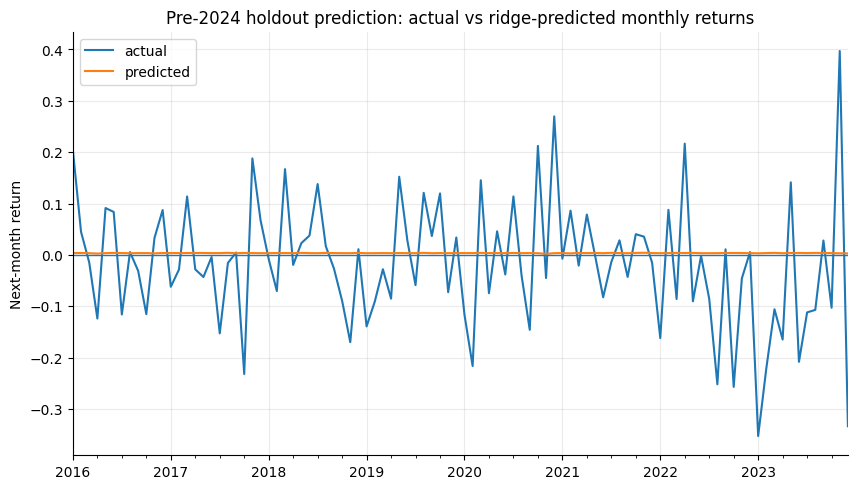

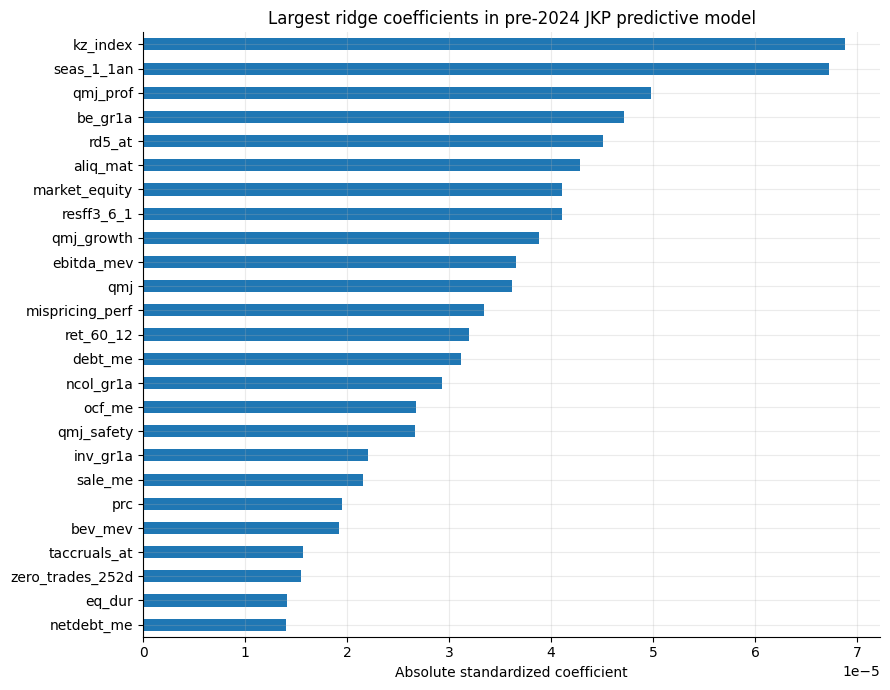

,abs_standardized_coef
kz_index,0.000069
seas_1_1an,0.000067
qmj_prof,0.000050
be_gr1a,0.000047
rd5_at,0.000045
aliq_mat,0.000043
market_equity,0.000041
resff3_6_1,0.000041
qmj_growth,0.000039
ebitda_mev,0.000037


In [22]:

if not pre_pred.empty:
    fig, ax = plt.subplots()
    pre_pred[['actual','predicted']].plot(ax=ax)
    ax.axhline(0, linewidth=1)
    ax.set_title('Pre-2024 holdout prediction: actual vs ridge-predicted monthly returns')
    ax.set_ylabel('Next-month return')
    plt.show()

    fig, ax = plt.subplots(figsize=(9,7))
    coef_importance.head(25).iloc[::-1].plot(kind='barh', ax=ax)
    ax.set_title('Largest ridge coefficients in pre-2024 JKP predictive model')
    ax.set_xlabel('Absolute standardized coefficient')
    plt.tight_layout()
    plt.show()
    display(coef_importance.head(25).to_frame('abs_standardized_coef'))
else:
    print(pre_metrics)



## 10. Fundamental ratios before and after 2024

This section uses the quarterly LUMN balance sheet and income-statement data to compare operating and balance-sheet fundamentals before and after the restructuring period. The purpose is not to rebuild the full financial-analysis notebook; it is to look for evidence that the underlying firm changed.


In [23]:

fin = read_csv_from_zip(PATHS['lumn_zip'], 'LUMN_quarterly_financials')
bs = read_csv_from_zip(PATHS['lumn_zip'], 'LUMN_quarterly_balance-sheet')

# Clean financial statement tables from yfinance-like format: first column is usually metric names.
def statement_to_wide(df):
    out = df.copy()
    metric_col = out.columns[0]
    out = out.rename(columns={metric_col: 'metric'})
    out['metric'] = out['metric'].astype(str)
    # Drop rows with empty metric names.
    out = out[out['metric'].notna()]
    value_cols = [c for c in out.columns if c != 'metric']
    # Dates are columns; transpose to date index.
    t = out.set_index('metric')[value_cols].T
    t.index = pd.to_datetime(t.index, errors='coerce')
    t = t[~t.index.isna()].sort_index()
    for c in t.columns:
        t[c] = pd.to_numeric(t[c].astype(str).str.replace(',', '', regex=False), errors='coerce')
    return t

fin_q = statement_to_wide(fin)
bs_q = statement_to_wide(bs)
stmt = fin_q.join(bs_q, how='outer', rsuffix='_bs').sort_index()
print('Statement dates:', stmt.index.min().date(), 'to', stmt.index.max().date(), '| columns:', stmt.shape[1])
stmt.tail(3)


Statement dates: 1986-03-31 to 2026-03-31 | columns: 152


metric,Total Revenue,\tOperating Revenue,Cost of Revenue,Gross Profit,Operating Expense,\tSelling General and Administrative,\t\tGeneral & Administrative Expense,\t\t\tSalaries and Wages,\t\t\tOther G and A,\tDepreciation Amortization Depletion,\t\tDepreciation & amortization,\t\t\tDepreciation,\t\t\tAmortization,\t\t\t\tAmortization of Intangibles,\tOther Operating Expenses,Operating Income,Net Non Operating Interest Income Expense,\tInterest Income Non Operating,\tInterest Expense Non Operating,Other Income Expense,\tGain on Sale of Security,\tEarnings from Equity Interest,\tSpecial Income Charges,\t\tImpairment of Capital Assets,\t\tOther Special Charges,\t\tGain on Sale of Business,\t\tGain on Sale of PPE,\tOther Non Operating Income Expenses,Pretax Income,Tax Provision,Net Income Common Stockholders,\tNet Income,\t\tNet Income Including Non-Controlling Interests,\t\t\tNet Income Continuous Operations,\t\t\tNet Income Discontinuous Operations,\t\t\tNet Income Extraordinary,\t\t\tNet Income from Tax Loss Carryforward,\t\tMinority Interests,\tPreferred Stock Dividends,\tOtherunder Preferred Stock Dividend,Diluted NI Available to Com Stockholders,Basic EPS,Diluted EPS,Basic Average Shares,Diluted Average Shares,Total Operating Income as Reported,Total Expenses,Net Income from Continuing & Discontinued Operation,Normalized Income,Interest Income,Interest Expense,Net Interest Income,EBIT,EBITDA,Reconciled Cost of Revenue,Reconciled Depreciation,Net Income from Continuing Operation Net Minority Interest,Total Unusual Items Excluding Goodwill,Total Unusual Items,Normalized EBITDA,...,\t\tGoodwill And Other Intangible Assets,\t\t\tGoodwill,\t\t\tOther Intangible Assets,\t\tOther Non Current Assets,Total Liabilities Net Minority Interest,\tCurrent Liabilities,\t\tPayables And Accrued Expenses,\t\t\tPayables,\t\t\t\tAccounts Payable,\t\t\t\tTotal Tax Payable,\t\t\t\t\tIncome Tax Payable,\t\t\t\tDividends Payable,\t\t\tCurrent Accrued Expenses,\t\t\t\tInterest Payable,\t\tCurrent Provisions,\t\tPension & Other Post Retirement Benefit Plans Current,\t\tCurrent Debt And Capital Lease Obligation,\t\t\tCurrent Debt,\t\t\t\tCurrent Notes Payable,\t\t\t\tOther Current Borrowings,\t\t\tCurrent Capital Lease Obligation,\t\tCurrent Deferred Liabilities,\t\t\tCurrent Deferred Revenue,\t\tOther Current Liabilities,\tTotal Non Current Liabilities Net Minority Interest,\t\tLong Term Debt And Capital Lease Obligation,\t\t\tLong Term Debt,\t\t\tLong Term Capital Lease Obligation,\t\tNon Current Deferred Liabilities,\t\t\tNon Current Deferred Taxes Liabilities,\t\t\tNon Current Deferred Revenue,\t\tEmployee Benefits,\t\t\tNon Current Pension And Other Post-Retirement Benefit Plans,\t\tOther Non Current Liabilities,Total Equity Gross Minority Interest,\tStockholders' Equity,\t\tCapital Stock,\t\t\tPreferred Stock,\t\t\tCommon Stock,\t\tAdditional Paid in Capital,\t\tRetained Earnings,\t\tTreasury Stock,\t\tGains Losses Not Affecting Retained Earnings,\t\t\tOther Equity Adjustments,\t\tOther Equity Interest,\tMinority Interest,Total Capitalization,Preferred Stock Equity,Common Stock Equity,Capital Lease Obligations,Net Tangible Assets,Working Capital,Invested Capital,Tangible Book Value,Total Debt,Net Debt,Share Issued,Ordinary Shares Number,Preferred Shares Number,Treasury Shares Number
2025-09-30,3087000000,3087000000,1.700000e+09,1.387000e+09,1.503000e+09,829000000.0,829000000.0,NaN,829000000.0,674000000.0,674000000.0,423000000.0,251000000.0,251000000.0,NaN,-116000000,-301000000.0,18000000.0,319000000.0,-396000000.0,-5000000.0,NaN,-395000000.0,0.0,395000000.0,0.0,NaN,4000000.0,-813000000.0,-192000000.0,-621000000.0,-621000000.0,-621000000,-621000000,NaN,NaN,NaN,NaN,NaN,NaN,-621000000.0,-0.62,-0.62,995998000.0,995998000.0,-116000000.0,3.203000e+09,-621000000.0,-315400000.0,18000000.0,319000000.0,-301000000.0,-494000000,180000000,1.700000e+09,674000000.0,-621000000.0,-400000000.0,-400000000.0,580000000,...,4.411000e+09,0.0,4.411000e+09,2.061000e+09,3

In [24]:

# Helper to find statement columns robustly.
def find_col(df, candidates):
    normalized = {re.sub(r'[^a-z0-9]', '', c.lower()): c for c in df.columns}
    for cand in candidates:
        key = re.sub(r'[^a-z0-9]', '', cand.lower())
        if key in normalized:
            return normalized[key]
    # fuzzy contains fallback
    for cand in candidates:
        key = re.sub(r'[^a-z0-9]', '', cand.lower())
        for norm, orig in normalized.items():
            if key in norm or norm in key:
                return orig
    return None

cols = {
    'revenue': find_col(stmt, ['Total Revenue','Operating Revenue','Revenue']),
    'gross_profit': find_col(stmt, ['Gross Profit']),
    'operating_income': find_col(stmt, ['Operating Income','Operating Income Loss']),
    'net_income': find_col(stmt, ['Net Income','Net Income Common Stockholders','Net Income From Continuing Operation Net Minority Interest']),
    'ebitda': find_col(stmt, ['EBITDA','Normalized EBITDA']),
    'interest_expense': find_col(stmt, ['Interest Expense','Interest Expense Non Operating']),
    'cash': find_col(stmt, ['Cash And Cash Equivalents','Cash Cash Equivalents And Short Term Investments']),
    'total_assets': find_col(stmt, ['Total Assets']),
    'current_assets': find_col(stmt, ['Current Assets','Total Current Assets']),
    'current_liabilities': find_col(stmt, ['Current Liabilities','Total Current Liabilities']),
    'total_debt': find_col(stmt, ['Total Debt']),
    'stockholders_equity': find_col(stmt, ['Stockholders Equity','Total Equity Gross Minority Interest','Common Stock Equity']),
}
cols


{'revenue': 'Total Revenue',
 'gross_profit': 'Gross Profit',
 'operating_income': 'Operating Income',
 'net_income': '\tNet Income',
 'ebitda': 'EBITDA',
 'interest_expense': 'Interest Expense',
 'cash': '\t\t\tCash And Cash Equivalents',
 'total_assets': 'Total Assets',
 'current_assets': '\tCurrent Assets',
 'current_liabilities': '\tCurrent Liabilities',
 'total_debt': 'Total Debt',
 'stockholders_equity': "\tStockholders' Equity"}

In [25]:

ratios = pd.DataFrame(index=stmt.index)
# Margins
if cols['revenue']:
    ratios['Revenue'] = stmt[cols['revenue']]
    if cols['gross_profit']:
        ratios['Gross margin'] = stmt[cols['gross_profit']] / stmt[cols['revenue']]
    if cols['operating_income']:
        ratios['Operating margin'] = stmt[cols['operating_income']] / stmt[cols['revenue']]
    if cols['net_income']:
        ratios['Net margin'] = stmt[cols['net_income']] / stmt[cols['revenue']]
    if cols['ebitda']:
        ratios['EBITDA margin'] = stmt[cols['ebitda']] / stmt[cols['revenue']]
# Profitability/efficiency
if cols['net_income'] and cols['total_assets']:
    ratios['ROA'] = stmt[cols['net_income']] / stmt[cols['total_assets']]
if cols['net_income'] and cols['stockholders_equity']:
    ratios['ROE'] = stmt[cols['net_income']] / stmt[cols['stockholders_equity']]
if cols['revenue'] and cols['total_assets']:
    ratios['Asset turnover'] = stmt[cols['revenue']] / stmt[cols['total_assets']]
# Liquidity/leverage
if cols['current_assets'] and cols['current_liabilities']:
    ratios['Current ratio'] = stmt[cols['current_assets']] / stmt[cols['current_liabilities']]
if cols['total_debt'] and cols['total_assets']:
    ratios['Debt/assets'] = stmt[cols['total_debt']] / stmt[cols['total_assets']]
if cols['total_debt'] and cols['stockholders_equity']:
    ratios['Debt/equity'] = stmt[cols['total_debt']] / stmt[cols['stockholders_equity']]
if cols['total_debt'] and cols['cash'] and cols['ebitda']:
    ratios['Net debt/EBITDA'] = (stmt[cols['total_debt']] - stmt[cols['cash']]) / stmt[cols['ebitda']]
if cols['ebitda'] and cols['interest_expense']:
    ratios['EBITDA/interest expense'] = stmt[cols['ebitda']] / stmt[cols['interest_expense']].abs()

# Growth rates based on quarterly data: YoY growth.
if 'Revenue' in ratios.columns:
    ratios['Revenue YoY growth'] = ratios['Revenue'].pct_change(4)
if cols['net_income']:
    ratios['Net income YoY growth'] = stmt[cols['net_income']].pct_change(4)
if cols['ebitda']:
    ratios['EBITDA YoY growth'] = stmt[cols['ebitda']].pct_change(4)

ratio_period_summary = pd.concat({
    'Pre-2024 mean': ratios.loc[:break_date - pd.Timedelta(days=1)].mean(numeric_only=True),
    'Post-2024 mean': ratios.loc[break_date:].mean(numeric_only=True),
    'Latest': ratios.dropna(how='all').iloc[-1],
}, axis=1)
ratio_period_summary['Post minus Pre'] = ratio_period_summary['Post-2024 mean'] - ratio_period_summary['Pre-2024 mean']
ratio_period_summary


,Pre-2024 mean,Post-2024 mean,Latest,Post minus Pre
Revenue,1.850855e+09,3.156556e+09,2.899000e+09,1.305700e+09
Gross margin,5.492547e-01,4.797975e-01,5.050017e-01,-6.945724e-02
Operating margin,2.505408e-01,9.551087e-03,2.069679e-03,-2.409897e-01
Net margin,7.824625e-02,-7.199887e-02,-6.898931e-02,-1.502451e-01
EBITDA margin,4.050379e-01,2.265243e-01,3.677130e-01,-1.785136e-01
ROA,5.999987e-03,-6.669820e-03,-6.531252e-03,-1.266981e-02
ROE,-4.322072e-02,1.426402e-01,1.518603e-01,1.858610e-01
Asset turnover,8.458095e-02,9.493666e-02,9.467050e-02,1.035571e-02
Current ratio,7.807393e-01,1.420811e+00,9.880125e-01,6.400713e-01
Debt/assets,4.284101e-01,5.330938e-01,4.326954e-01,1.046837e-01


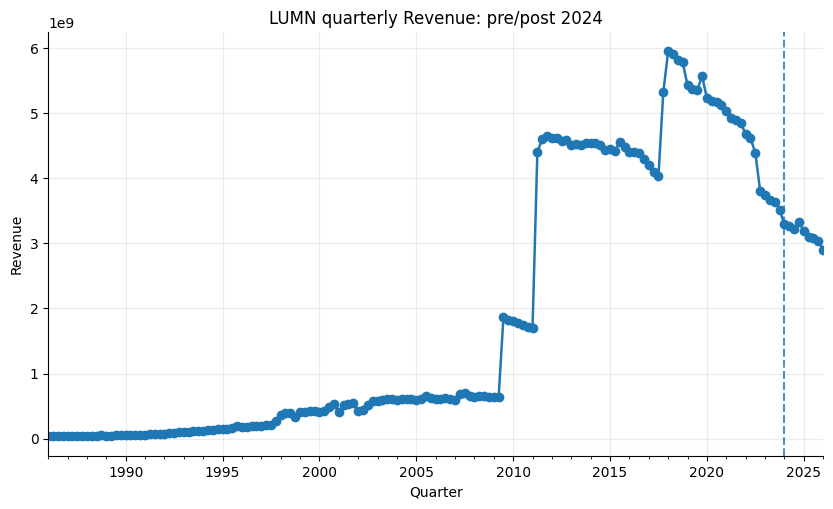

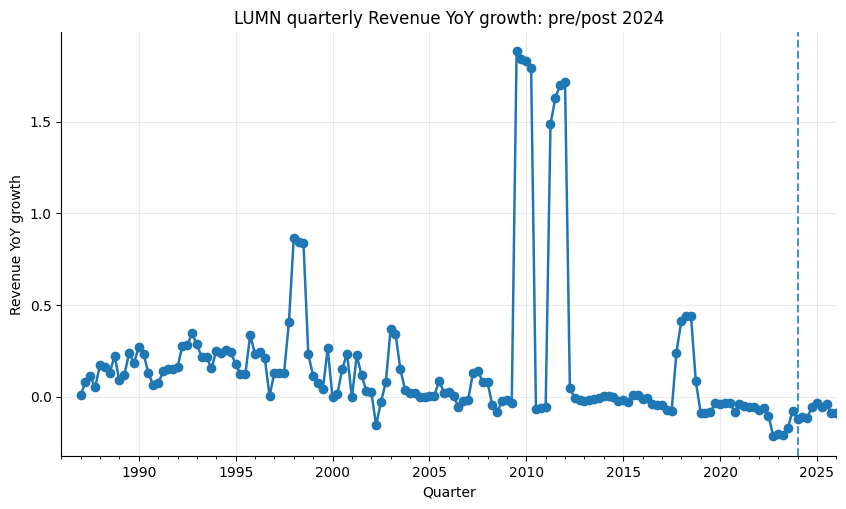

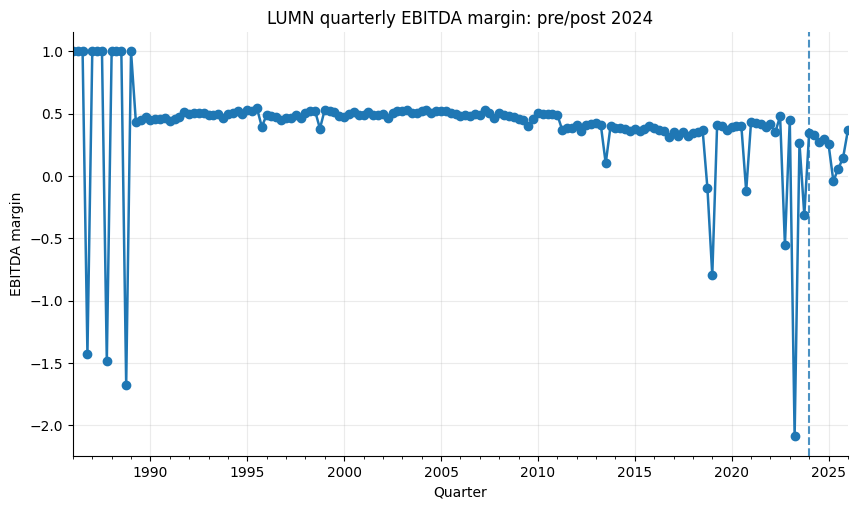

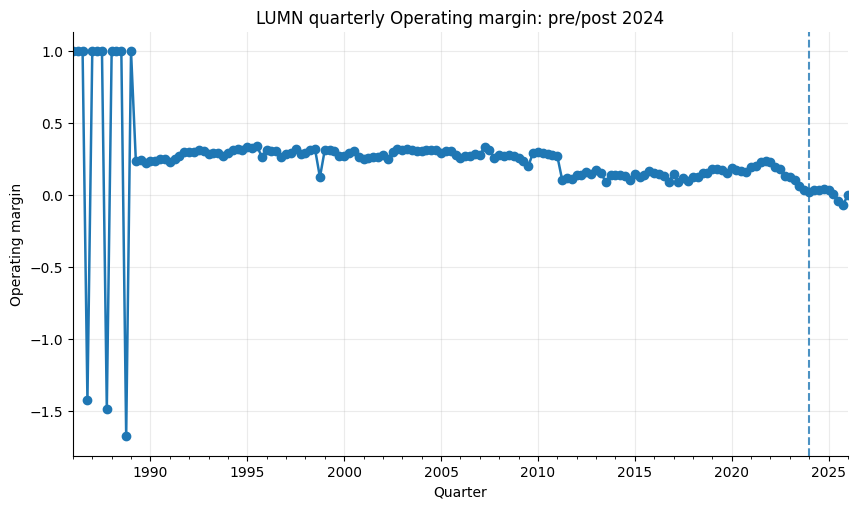

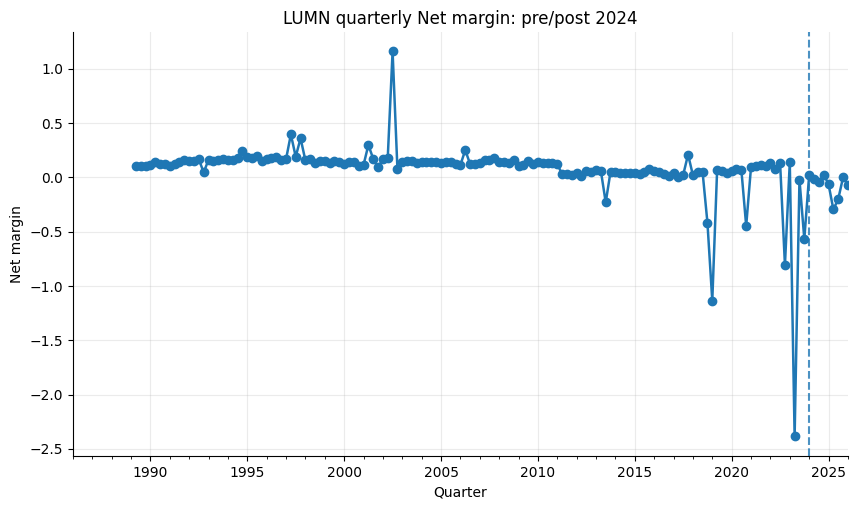

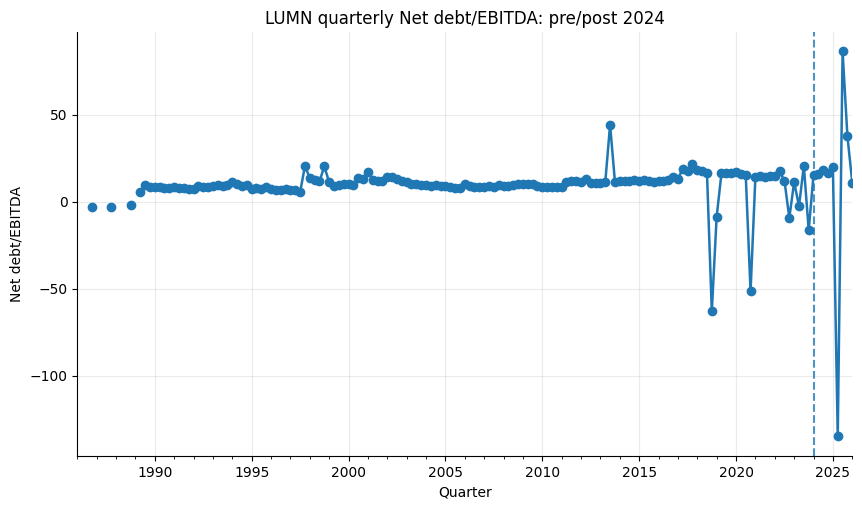

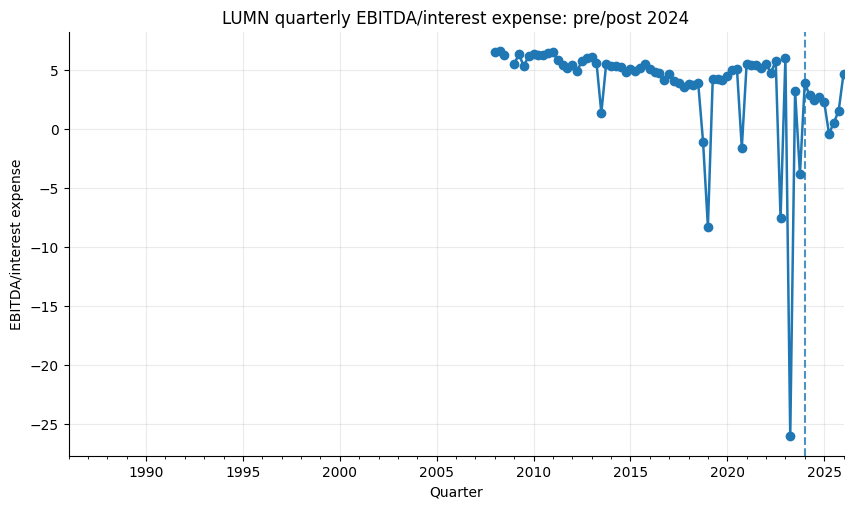

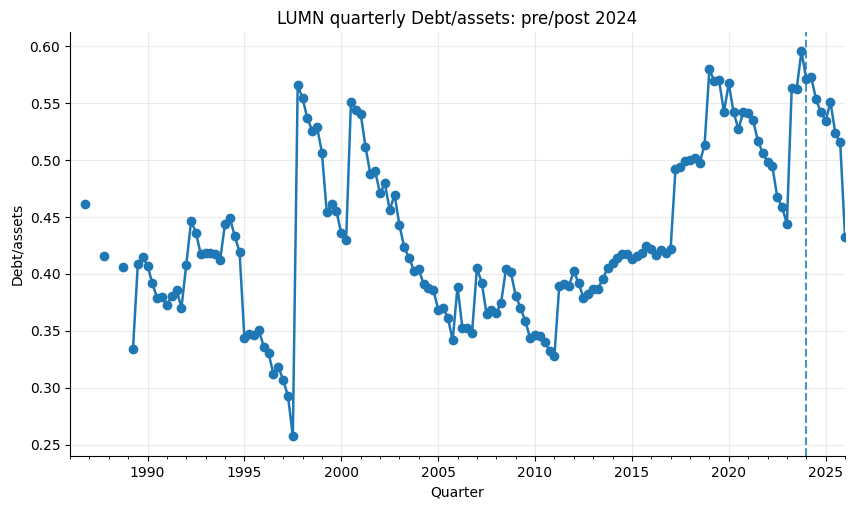

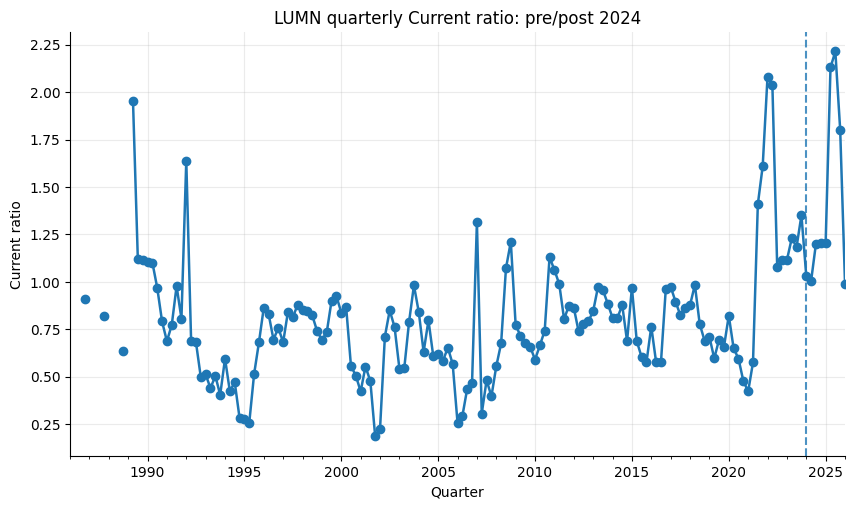

In [26]:

key_ratio_cols = [c for c in ['Revenue','Revenue YoY growth','EBITDA margin','Operating margin','Net margin','Net debt/EBITDA','EBITDA/interest expense','Debt/assets','Current ratio'] if c in ratios.columns]
for col in key_ratio_cols:
    fig, ax = plt.subplots()
    ratios[col].plot(ax=ax, marker='o', linewidth=1.8)
    ax.axvline(break_date, linestyle='--', alpha=0.8)
    ax.set_title(f'LUMN quarterly {col}: pre/post 2024')
    ax.set_xlabel('Quarter')
    ax.set_ylabel(col)
    plt.show()



## 11. Peer context around the break

The peer analysis below is deliberately narrower than the main notebook. It compares post-2024 price performance and basic return statistics across LUMN, CCOI, DTEGY, T, VOD, and VZ. DTEGY and VOD accounting data are in EUR in the source files; this price-return comparison uses the ADR/share-price files and is therefore unaffected by the accounting-currency issue.


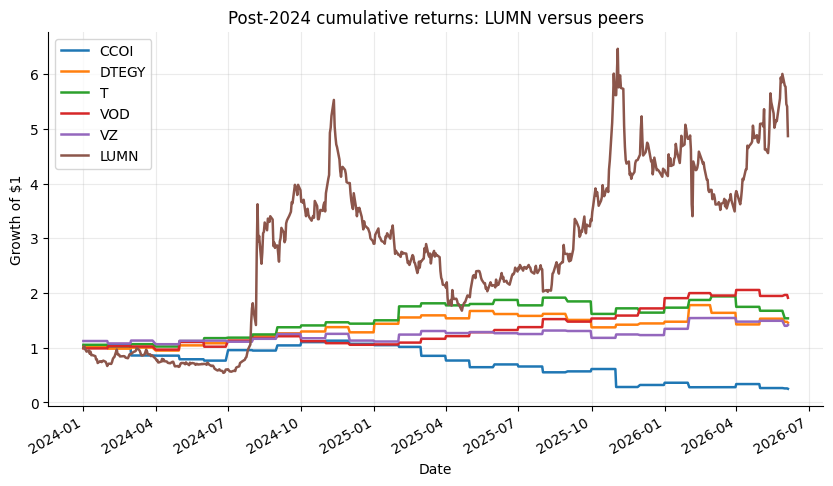

,Pre-2024 ann. return,Pre-2024 ann. vol,Post-2024 ann. return,Post-2024 ann. vol,Post-2024 skew,Post-2024 excess kurtosis
LUMN,-0.128880,0.402563,0.898923,1.024561,5.364817,71.050307
VOD,-0.002878,0.248484,0.300673,0.209618,4.796755,50.637122
T,0.066608,0.184850,0.190477,0.228640,2.710125,55.886773
DTEGY,0.096901,0.242156,0.164864,0.250717,3.899012,68.292605
VZ,0.073025,0.171662,0.151606,0.220571,3.574230,50.723699
CCOI,0.186147,0.282477,-0.429365,0.530117,-7.144927,124.107343


In [27]:

def load_peer_prices(peers_zip):
    prices = {}
    with zipfile.ZipFile(peers_zip, 'r') as z:
        members = [m for m in z.namelist() if m.lower().endswith('.csv') and 'quarterly' not in m.lower() and 'annual' not in m.lower()]
        for m in members:
            ticker = Path(m).stem.upper()
            with z.open(m) as f:
                df = pd.read_csv(f)
            df = clean_price_data(df)
            col = pick_price_col(df)
            prices[ticker] = df[col]
    # Add LUMN
    prices['LUMN'] = lumn_daily[price_col_daily]
    return pd.DataFrame(prices).sort_index()

peer_prices = load_peer_prices(PATHS['peers_zip']).loc[ASSUMPTIONS['analysis_start_date']:]
peer_returns = peer_prices.pct_change()
peer_post = peer_returns.loc[break_date:]
peer_pre = peer_returns.loc[:break_date - pd.Timedelta(days=1)]

peer_post_wealth = (1 + peer_post.dropna(how='all')).cumprod()
fig, ax = plt.subplots()
peer_post_wealth.plot(ax=ax, linewidth=1.8)
ax.set_title('Post-2024 cumulative returns: LUMN versus peers')
ax.set_ylabel('Growth of $1')
plt.show()

peer_stats = pd.concat({
    'Pre-2024 ann. return': peer_pre.apply(lambda s: ann_return_from_periodic(s.dropna(), 252)),
    'Pre-2024 ann. vol': peer_pre.std()*np.sqrt(252),
    'Post-2024 ann. return': peer_post.apply(lambda s: ann_return_from_periodic(s.dropna(), 252)),
    'Post-2024 ann. vol': peer_post.std()*np.sqrt(252),
    'Post-2024 skew': peer_post.skew(),
    'Post-2024 excess kurtosis': peer_post.kurt(),
}, axis=1)
peer_stats.sort_values('Post-2024 ann. return', ascending=False)



## 12. Interpretation and investment implications

This final section programmatically summarizes the major empirical differences found above. The interpretation is intentionally conservative because the post-2024 sample is short and may be dominated by a few event-driven price jumps.


In [28]:

summary_rows = []
# Return stats key differences
m_pre = monthly_stats.loc['Pre-2024']
m_post = monthly_stats.loc['Post-2024']
d_pre = daily_ff5_table.loc['Daily Pre-2024']
d_post = daily_ff5_table.loc['Daily Post-2024']
summary_rows.append(['Monthly cumulative return', m_pre['cumulative_return'], m_post['cumulative_return'], m_post['cumulative_return']-m_pre['cumulative_return']])
summary_rows.append(['Monthly annualized volatility', m_pre['annualized_volatility'], m_post['annualized_volatility'], m_post['annualized_volatility']-m_pre['annualized_volatility']])
summary_rows.append(['Monthly skewness', m_pre['skewness'], m_post['skewness'], m_post['skewness']-m_pre['skewness']])
summary_rows.append(['Daily FF5 market beta', d_pre['beta_Mkt-RF'], d_post['beta_Mkt-RF'], d_post['beta_Mkt-RF']-d_pre['beta_Mkt-RF']])
summary_rows.append(['Daily FF5 cost of equity', d_pre['cost_of_equity_FF5'], d_post['cost_of_equity_FF5'], d_post['cost_of_equity_FF5']-d_pre['cost_of_equity_FF5']])
summary_table = pd.DataFrame(summary_rows, columns=['Metric','Pre-2024','Post-2024','Change']).set_index('Metric')
summary_table


,Pre-2024,Post-2024,Change
Metric,,,
Monthly cumulative return,-0.857174,3.868852,4.726027
Monthly annualized volatility,0.347612,1.436543,1.088931
Monthly skewness,0.113491,2.842296,2.728806
Daily FF5 market beta,0.938312,1.859873,0.921561
Daily FF5 cost of equity,0.122671,0.157482,0.034811



### Notebook conclusion

The evidence supports a structural-break interpretation: **after 2024, LUMN traded like a different security**. The pre-2024 stock looked like a declining, levered incumbent with poor long-run compounded returns. The post-2024 stock looks more like a high-beta, high-volatility, event-driven turnaround option.

The most important empirical differences are:

- **Return distribution:** post-2024 returns are much larger but also much more volatile, skewed, and fat-tailed.
- **Market exposure:** daily FF5 market beta rises substantially after 2024, indicating that equity holders face a higher systematic-risk burden.
- **Cost of equity:** the higher post-2024 beta and changed factor profile increase the estimated cost of equity. A successful turnaround must therefore clear a higher required-return hurdle.
- **Factor identity:** the JKP factor screen indicates that post-2024 LUMN is more closely tied to speculative, distress, quality, illiquidity, and default-risk-related factor themes than to stable quality/profitability themes.
- **Predictability:** the 153-factor set is diagnostically useful, but its predictive value remains weak after proper caution about multiple testing and limited post-2024 observations.
- **Fundamentals:** the post-2024 financial-statement comparison should be interpreted cautiously, but the key questions are whether revenue declines slow, margins recover, free cash flow becomes recurring rather than transaction-aided, and leverage/coverage improve materially.

**Investment implication:** the restructuring improves the optionality of the equity but does not automatically convert LUMN into a high-quality fundamental buy. A reasonable characterization is:

> Pre-2024 LUMN was a deteriorating, value-destructive telecom equity. Post-2024 LUMN is a speculative, levered turnaround option. The risk profile changed materially, and the cost of equity rose. A buy thesis requires confidence that the restructuring creates durable free cash flow and balance-sheet repair sufficient to overcome the higher required return.

For a conservative long-only investor, this remains an **avoid/sell** until post-restructuring operating improvements are visible in recurring cash flow, leverage, and interest coverage. For a speculative investor, it may be a **watchlist/turnaround trade**, but the appropriate valuation method should explicitly account for option-like payoff asymmetry, high beta, and the elevated cost of equity.
